#  Weekly Dynamic Regression with Dominant Variant (Germany)



[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/07_DynamicRegression_AllLineages_Germany.ipynb)
---


## Mathematical model used in this notebook

### AutoRegressive model with eXogenous variables (ARX )
We model the log-transformed weekly cases:

$
z_t =
\phi_1 z_{t-1}+\phi_2 z_{t-2}+\phi_3 z_{t-3}
+ \beta_V V_{t-2}
+ \beta_S S_t
+ \beta_{VS}(V_{t-2}\cdot C_t)
+ \sum_{k=1}^{K-1}\gamma_k \mathbb{1}\{C_t = c_k\}
+ \varepsilon_t.
$

- AR(3): short-term memory of the epidemic curve
- Vaccination lag $V_{t-2}$: simple delay between vaccination and effect
- Stringency $S_t$: policy/behavior proxy
- Interaction $V_{t-2}\cdot C_t$: one combined “driver” 
- Variant dummies: one‑hot encoding of dominant lineage (with one reference category)

### Ridge estimator 
Many predictors are correlated (lags, interaction, policy trends). Ridge stabilizes estimation:

$
\hat\beta = \arg\min_\beta \|z - X\beta\|_2^2 + \alpha\|\beta\|_2^2.
$

- $\alpha \to 0$: nearly ordinary least squares  
- large $\alpha$: stronger shrinkage (smaller coefficients), usually better generalization

Because Ridge depends on feature scale, we **standardize** predictors before fitting.

## 1) Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

country = "Germany"

owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
variant_url = "https://raw.githubusercontent.com/EU-ECDC/Respiratory_viruses_weekly_data/refs/heads/main/data/variants.csv"

## 2) Load OWID daily data and define vaccination start

We use:
- `new_cases_smoothed` (daily, already smoothed)
- `stringency_index`
- `people_vaccinated_per_hundred`

Vaccination start is defined as the first day with `people_vaccinated_per_hundred > 0`.

In [2]:
df_daily = pd.read_csv(owid_url, parse_dates=["date"])

df_daily = df_daily[df_daily["location"] == country][[
    "date",
    "new_cases_smoothed",
    "stringency_index",
    "people_vaccinated_per_hundred"
]].dropna()

df_daily = df_daily[df_daily["date"] >= "2020-03-01"].sort_values("date").reset_index(drop=True)

vacc_start = df_daily.loc[df_daily["people_vaccinated_per_hundred"] > 0, "date"].min()
vacc_start

Timestamp('2020-12-27 00:00:00')

## 3) Aggregate OWID to weekly (W-MON)


- Variant data is weekly.
- Weekly modeling is more stable and reduces noise.

Weekly aggregation:
- Cases: weekly **mean** of smoothed daily cases
- Vaccination: **last** value in the week
- Stringency: weekly **mean**

In [3]:
df_weekly = (
    df_daily
    .set_index("date")
    .resample("W-MON")
    .agg({
        "new_cases_smoothed": "mean",
        "people_vaccinated_per_hundred": "last",
        "stringency_index": "mean"
    })
    .dropna()
)

# Restrict to vaccination period
df_weekly = df_weekly.loc[df_weekly.index >= vacc_start].copy()

df_weekly.head(), df_weekly.tail()

(            new_cases_smoothed  people_vaccinated_per_hundred  \
 date                                                            
 2020-12-28        19832.570000                           0.05   
 2021-01-04        19184.610000                           0.42   
 2021-01-11        18485.201429                           0.90   
 2021-01-18        19701.695714                           1.52   
 2021-01-25        16035.737143                           2.02   
 
             stringency_index  
 date                          
 2020-12-28         82.410000  
 2021-01-04         82.410000  
 2021-01-11         84.658571  
 2021-01-18         83.330000  
 2021-01-25         83.330000  ,
             new_cases_smoothed  people_vaccinated_per_hundred  \
 date                                                            
 2022-12-05        24950.920000                          77.79   
 2022-12-12        27002.752857                          77.80   
 2022-12-19        29457.772857                

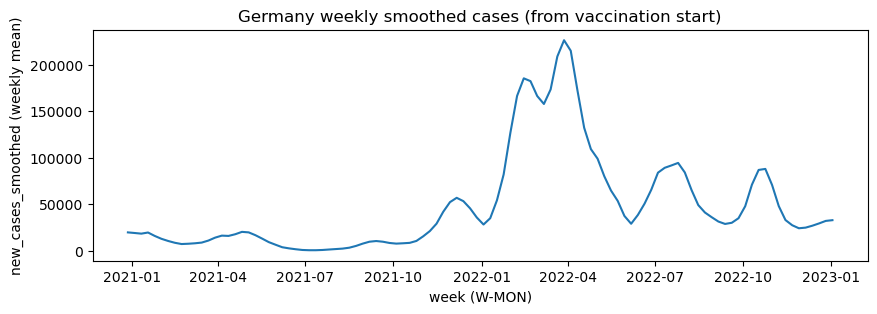

In [4]:
plt.figure(figsize=(10, 3))
plt.plot(df_weekly.index, df_weekly["new_cases_smoothed"])
plt.title("Germany weekly smoothed cases (from vaccination start)")
plt.xlabel("week (W-MON)")
plt.ylabel("new_cases_smoothed (weekly mean)")
plt.show()

## 4) Load variant proportions (ECDC) and compute dominant lineage

### ISO year-week → date
ECDC uses `yearweek` like `2021-W25`.  
We map it to the **Monday** of that ISO week using:
`pd.to_datetime(yearweek + "-1", format="%G-W%V-%u")`

- `%G`: ISO year
- `%V`: ISO week number
- `%u`: ISO weekday (1 = Monday)

### Dominant lineage per week
For each week, we select the row with maximum `value` (proportion).

In [5]:
var = pd.read_csv(variant_url)

# Filter Germany + SARS-CoV-2 + proportion + total age
var = var[
    (var["countryname"] == country) &
    (var["pathogen"] == "SARS-CoV-2") &
    (var["indicator"] == "proportion") &
    (var["age"] == "total")
].copy()

# ISO week -> Monday of that week
var["week_start"] = pd.to_datetime(var["yearweek"] + "-1", format="%G-W%V-%u", errors="coerce")
var = var.dropna(subset=["week_start"])

# Dominant lineage per week
dominant = var.loc[var.groupby("week_start")["value"].idxmax(), ["week_start", "variant"]]
dominant = dominant.sort_values("week_start").reset_index(drop=True)

dominant.head(), dominant.tail()

(  week_start    variant
 0 2021-06-21  B.1.617.2
 1 2021-06-28  B.1.617.2
 2 2021-07-05  B.1.617.2
 3 2021-07-12  B.1.617.2
 4 2021-07-19  B.1.617.2,
     week_start   variant
 237 2026-01-05  NB.1.8.1
 238 2026-01-12       XFG
 239 2026-01-19  NB.1.8.1
 240 2026-01-26  NB.1.8.1
 241 2026-02-02  NB.1.8.1)

## 5) Merge dominant lineage into weekly OWID table (no NaNs)

We merge on the shared weekly date index (Monday).

If variant reporting has occasional missing weeks, we forward-fill **at weekly resolution**.

In [6]:
df_weekly = df_weekly.reset_index().rename(columns={"date": "week_start"})
df_weekly = df_weekly.merge(dominant, on="week_start", how="left").sort_values("week_start")

# Forward-fill any missing weekly variants (rare; depends on reporting)
df_weekly["variant"] = df_weekly["variant"].ffill()

# If some early weeks still have missing (e.g., variant surveillance starts later),
# we can drop them for modeling to avoid leakage/ambiguity.
df_weekly = df_weekly.dropna(subset=["variant"]).reset_index(drop=True)

df_weekly.head(10)

,week_start,new_cases_smoothed,people_vaccinated_per_hundred,stringency_index,variant
0,2021-06-21,1732.245714,52.38,69.440000,B.1.617.2
1,2021-06-28,941.690000,55.34,69.440000,B.1.617.2
2,2021-07-05,674.917143,58.09,69.440000,B.1.617.2
3,2021-07-12,676.205714,59.91,69.440000,B.1.617.2
4,2021-07-19,943.081429,61.21,69.440000,B.1.617.2
5,2021-07-26,1446.062857,62.15,69.440000,B.1.617.2
6,2021-08-02,1923.958571,62.94,68.648571,B.1.617.2
7,2021-08-09,2417.470000,63.61,61.110000,B.1.617.2
8,2021-08-16,3393.244286,64.39,61.110000,B.1.617.2
9,2021-08-23,5299.775714,65.27,57.365714,B.1.617.2


In [7]:
# Sanity check: any remaining NaNs?
df_weekly.isna().sum()

week_start                       0
new_cases_smoothed               0
people_vaccinated_per_hundred    0
stringency_index                 0
variant                          0
dtype: int64

# Modeling

We model weekly log-cases using:

- AR(3): lags of z_t = log(weekly_cases + 1)
- Vaccination lag: 2 weeks
- Stringency index
- Dominant variant: one-hot encoding
- Interaction: vaccination × variants

Estimator:
- Ridge regression (scaled predictors)
- Compare vs baselines
- Coefficient-based feature importance

## 6) Feature engineering (no leakage)

# Understanding Variant One-Hot Encoding 

## 1. Why do we need encoding?

The column `variant` contains **categorical values**, for example:

| week_start | variant      |
|------------|-------------|
| 2021-06-21 | B.1.617.2   |
| 2022-01-10 | BA.1        |
| 2022-03-07 | BA.2        |

Machine learning models (Ridge, ElasticNet, RandomForest) cannot work with text labels directly.  
They require **numerical input**.

Therefore, we convert the categorical variable into numeric indicator variables.

---

## 2. What is One-Hot Encoding?

Suppose we have the following variants:

- B.1.617.2  (Delta)
- BA.1
- BA.2
- BA.5
- BQ.1

One-hot encoding creates binary (0/1) columns:

| variant      | var_BA.1 | var_BA.2 | var_BA.5 | var_BQ.1 |
|-------------|----------|----------|----------|----------|
| B.1.617.2   | 0        | 0        | 0        | 0        |
| BA.1        | 1        | 0        | 0        | 0        |
| BA.2        | 0        | 1        | 0        | 0        |
| BA.5        | 0        | 0        | 1        | 0        |
| BQ.1        | 0        | 0        | 0        | 1        |

Each row belongs to exactly one variant.

---

## 3. Why do we use `drop_first=True`?

If we created dummy variables for **all** categories, we would have:

$
var_1 + var_2 + \dots + var_K = 1
$

This creates **perfect multicollinearity** (dummy variable trap).

To avoid this, we drop one category:

```python
variant_dummies = pd.get_dummies(
    df_weekly["variant"],
    prefix="var",
    drop_first=True
)
```

In [8]:
# Target
df_weekly["z"] = np.log1p(df_weekly["new_cases_smoothed"])

# AR(3)
for lag in [1, 2, 3]:
    df_weekly[f"z_lag{lag}"] = df_weekly["z"].shift(lag)

# Vaccination lag
df_weekly["vacc_lag2"] = df_weekly["people_vaccinated_per_hundred"].shift(2)

# Variant one-hot encoding
variant_dummies = pd.get_dummies(df_weekly["variant"], prefix="var", drop_first=True)
df_weekly = pd.concat([df_weekly, variant_dummies], axis=1)

# Interaction terms
for col in variant_dummies.columns:
    df_weekly[f"{col}_x_vacc"] = df_weekly["vacc_lag2"] * df_weekly[col]

df_model = df_weekly.dropna().copy()

feature_cols = (
    ["z_lag1", "z_lag2", "z_lag3", "vacc_lag2"] +
    list(variant_dummies.columns) +
    [f"{col}_x_vacc" for col in variant_dummies.columns]
)

X = df_model[feature_cols]
y = df_model["z"]



In [9]:
df_model["variant"].value_counts()

BA.5         30
B.1.617.2    24
BA.2         15
BA.1          8
BQ.1          1
Name: variant, dtype: int64

In [10]:
df_model["variant"].unique()

array(['B.1.617.2', 'BA.1', 'BA.2', 'BA.5', 'BQ.1'], dtype=object)

In [11]:
X.head()

,z_lag1,z_lag2,z_lag3,vacc_lag2,var_BA.1,var_BA.2,var_BA.5,var_BQ.1,var_BA.1_x_vacc,var_BA.2_x_vacc,var_BA.5_x_vacc,var_BQ.1_x_vacc
3,6.516070,6.848737,7.457751,55.34,0,0,0,0,0.0,0.0,0.0,0.0
4,6.517975,6.516070,6.848737,58.09,0,0,0,0,0.0,0.0,0.0,0.0
5,6.850212,6.517975,6.516070,59.91,0,0,0,0,0.0,0.0,0.0,0.0
6,7.277291,6.850212,6.517975,61.21,0,0,0,0,0.0,0.0,0.0,0.0
7,7.562660,7.277291,6.850212,62.15,0,0,0,0,0.0,0.0,0.0,0.0


## 7) Baselines

# Model Evaluation Metrics — Explanation and Interpretation

In this notebook, we evaluate models using several complementary metrics.

Because we model:

$
z_t = \log(1 + y_t),
$

all reported metrics (unless otherwise stated) are computed in **log-scale**.

---

## 1. Mean Absolute Error (MAE)

$
MAE = \frac{1}{n} \sum_{t=1}^{n} |z_t - \hat z_t|
$

### Interpretation
- Measures the **average absolute prediction error**.
- Same unit as the target (here: log-cases).
- More robust to large outliers than RMSE.

If MAE = 0.07 (log-scale), this corresponds approximately to:

$
e^{0.07} \approx 1.072
$

→ About **7% multiplicative error** in case counts.

---

## 2. Root Mean Squared Error (RMSE)

$
RMSE = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (z_t - \hat z_t)^2}
$

### Interpretation
- Penalizes large errors more than MAE.
- Sensitive to epidemic peaks.
- Same unit as log-cases.

If RMSE is much larger than MAE, it indicates occasional large prediction errors.

---

## 3. R² — Coefficient of Determination

$
R^2 = 1 - \frac{\sum (z_t - \hat z_t)^2}
{\sum (z_t - \bar z)^2}
$

### Interpretation
- Measures how much variance is explained.
- R² = 1 → perfect fit.
- R² = 0 → same as predicting the mean.
- R² < 0 → worse than mean model.

 In time series, $R^2$ can appear artificially high because of autocorrelation.
Always compare against persistence baseline.

---

## 4. MASE — Mean Absolute Scaled Error

$
MASE = \frac{MAE_{model}}{MAE_{naive}}
$

Where the naive forecast is:

$
\hat z_t = z_{t-1}
$

### Interpretation

- MASE < 1 → model is better than naive persistence
- MASE = 1 → same as naive
- MASE > 1 → worse than naive

MASE is particularly useful for time-series evaluation.

---

# How to Interpret Results in This Notebook

### Step 1 — Check Baselines First

Compare your model against:

- Persistence (z_t = z_{t-1})
- Mean model

If your model does not outperform persistence, it is not adding value.

---

### Step 2 — Compare MAE and RMSE

- Lower is better.
- If RMSE >> MAE → large occasional errors.
- If both decrease relative to baseline → improvement.

---

### Step 3 — Interpret R² Carefully

A high R² does not guarantee good forecasting.
Always compare against the persistence baseline.

---

### Step 4 — Interpret in Log Scale

Because we model log(1 + cases):

An error of 0.1 in log-scale means roughly:

$
e^{0.1} \approx 1.105
$

→ About 10.5% error in case counts.

If you want interpretation in original scale:

```python
y_true_cases = np.expm1(y_true)
y_pred_cases = np.expm1(y_pred)
```

In [12]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Persistence
mae_p, rmse_p = evaluate(y, df_model["z_lag1"])

# Mean baseline
mean_pred = np.repeat(y.mean(), len(y))
mae_m, rmse_m = evaluate(y, mean_pred)

(mae_p, rmse_p, mae_m, rmse_m)

(0.19572160701858618,
 0.23155408791115595,
 0.9460899101660066,
 1.2720032849155374)

## 8) Ridge regression with time-series cross-validation

Pipeline:
- StandardScaler
- Ridge

We tune alpha on a log-spaced grid with TimeSeriesSplit.

# Hyperparameter Tuning in Ridge: Understanding `np.logspace(-3, 3, 13)`

In our model we define:

```python
param_grid = {"ridge__alpha": np.logspace(-3, 3, 13)}
```
generates n values evenly spaced on a logarithmic scale between:
$10^a$ and $10^b$

 
here $n = 13 , a=-3, b= 3$
 


## Careful! first you need to split the sta into train and test then fit the train data in grid.fit() and in .predict() check on test data

In [13]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {"ridge__alpha": np.logspace(-3, 3, 13)}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(pipe, param_grid=param_grid, cv=tscv)
grid.fit(X, y)

best_model = grid.best_estimator_
best_alpha = grid.best_params_["ridge__alpha"]

best_alpha

0.001

In [14]:
# In-sample fitted values (for quick visualization)
y_hat = best_model.predict(X)
mae_r, rmse_r = evaluate(y, y_hat)

(mae_r, rmse_r)

(0.0731433140367703, 0.09615068716289837)

## 9) Feature importance (standardized coefficients)

Because we standardize predictors inside the pipeline,
the Ridge coefficients can be compared in magnitude.

In [15]:
coefs = best_model.named_steps["ridge"].coef_

importance = (
    pd.DataFrame({"feature": feature_cols, "coef": coefs})
    .assign(abs_coef=lambda d: np.abs(d["coef"]))
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

importance.head(25)

,feature,coef,abs_coef
0,z_lag1,2.721803,2.721803
1,var_BA.2_x_vacc,-2.326678,2.326678
2,var_BA.2,2.319192,2.319192
3,z_lag2,-2.137978,2.137978
4,var_BA.1_x_vacc,0.756530,0.756530
5,var_BA.5_x_vacc,-0.751262,0.751262
6,var_BA.1,-0.742548,0.742548
7,var_BA.5,0.722278,0.722278
8,z_lag3,0.610250,0.610250
9,vacc_lag2,0.077797,0.077797


In [18]:
# Extract coefficients from trained Ridge model
coefs = best_model.named_steps["ridge"].coef_
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": coefs
})


# How to Interpret the Visualizations


---

## Coefficient Forest Plot (Standardized Ridge Coefficients)

This plot shows all standardized coefficients sorted by magnitude.

Because predictors were standardized:

- Coefficients are comparable in size.
- Larger absolute value → stronger relative influence.

---

### How to Read the Forest Plot

- Horizontal axis → coefficient value.
- Vertical line at 0 → no effect.
- Bars to the right → positive association.
- Bars to the left → negative association.

---

### What to Expect in Epidemic Models

1. **AR terms (z_lag1, z_lag2, z_lag3)**  
   Usually largest coefficients.  
   → Epidemic momentum dominates.

2. **Variant main effects**  
   Shift overall level of cases.

3. **Interaction terms**  
   Modify vaccination slope by lineage.

4. **Rare variants**  
   Often small coefficients due to limited data and Ridge shrinkage.





## Caution About Over-Interpretation


- Association does not imply causation.
- Vaccination and variant periods are correlated with time.
- Confounding may exist.
- Ridge shrinks coefficients toward zero.

The model provides structured statistical insight, not causal proof.


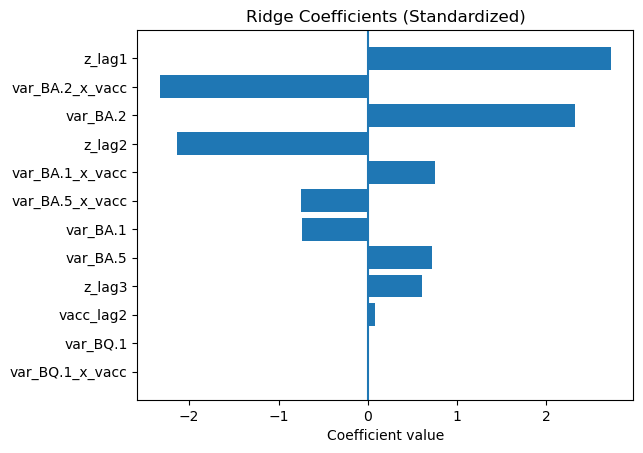

In [19]:
# Sort by absolute value
coef_plot = coef_df.copy()
coef_plot["abs_coef"] = np.abs(coef_plot["coef"])
coef_plot = coef_plot.sort_values("abs_coef", ascending=True)

plt.figure()
plt.barh(coef_plot["feature"], coef_plot["coef"])
plt.axvline(0)
plt.title("Ridge Coefficients (Standardized)")
plt.xlabel("Coefficient value")
plt.show()

## 10) Model comparison (baselines vs Ridge)

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Persistence", "Mean", "Ridge (tuned alpha)"],
    "MAE": [mae_p, mae_m, mae_r],
    "RMSE": [rmse_p, rmse_m, rmse_r]
})

comparison

## 11) Visual check: fitted vs observed

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(df_model["week_start"], y.values, label="observed z=log1p(cases)")
plt.plot(df_model["week_start"], y_hat, label="fitted z-hat")
plt.title("Weekly Ridge dynamic regression (vaccination period)")
plt.xlabel("week")
plt.ylabel("log1p(smoothed cases)")
plt.legend()
plt.show()